## Why: Understanding (More) Autonomous Systems Resilience {.smaller}



:::: {.columns}

::: {.column width="35%"}
![](../../docs-source/figures/drawio/autonomy_resilience.svg)
:::
::: {.column width="65%"}
- Autonomy presents major challenges to existing hazard simulation methodologies
- Need to better account for interactions between human/autonomous operators, engineered system(s) and the environment
- Rover acts as testbed for new methods for modeling human/system/environment interactions 
:::
::::

## Rover Model Structure {.smaller}

:::: {.columns}
::: {.column width="40%"}

The main functions are:

- `power`, the power supply

- `communications`, the radio that relays position to operators

- `plan_path`, the planner that determines where to go given its current position

- `override`, the system that enables the operator to control the rover

- `perception`, the camera/AI system that perceives the ground 

- `environment`, which defines the line the rover must follow

:::
::: {.column width="60%"}

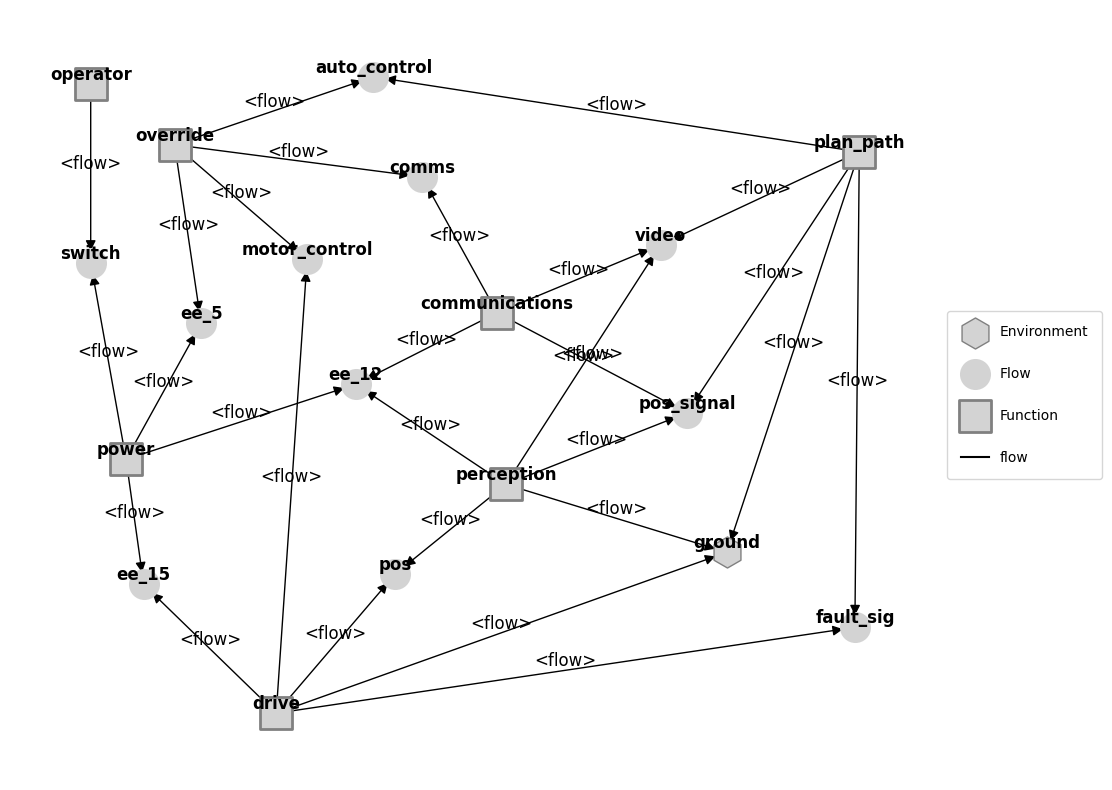

In [2]:
#| echo: true
from model_main import Rover, pos, plot_map
mg = Rover().as_modelgraph()
mg.set_pos(**pos)
fig, ax = mg.draw()

:::
::::

## Rover Environment

The rover is designed to follow a line from its start to its destination. The rover has two environments that it can navigate through: a sine wave and an L-shaped curve

:::: {.columns}
::: {.column width="60%"}

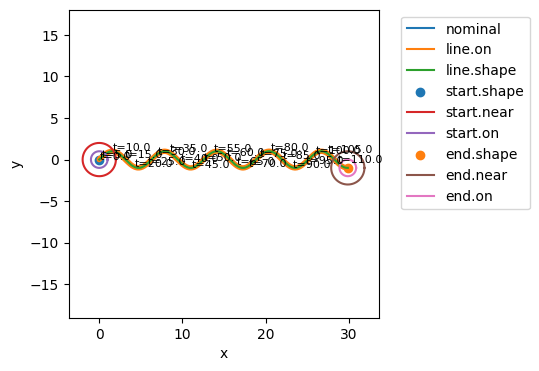

In [3]:
from fmdtools.sim import propagate
mdl = Rover()
res, hist = propagate.nominal(mdl)
fig, ax = plot_map(mdl, hist)

:::
::: {.column width="40%"}

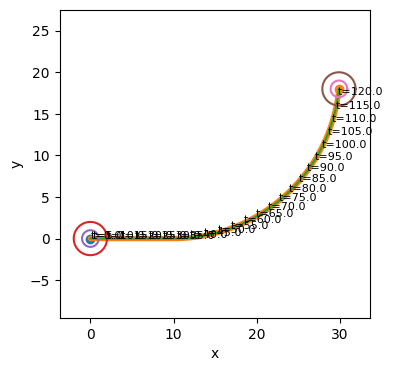

In [4]:
mdl = Rover(p={'ground': {'linetype': 'turn'}})
res, hist = propagate.nominal(mdl)
fig, ax = plot_map(mdl, hist, coord_kwargs=dict(legend=False), legend=False)

:::
::::

## Human Modeling

To better represent human actions and behaviors, the human rover model represents the operator as an `ActionArchitecture` of actions that the human operator is expected to perform in sequence.

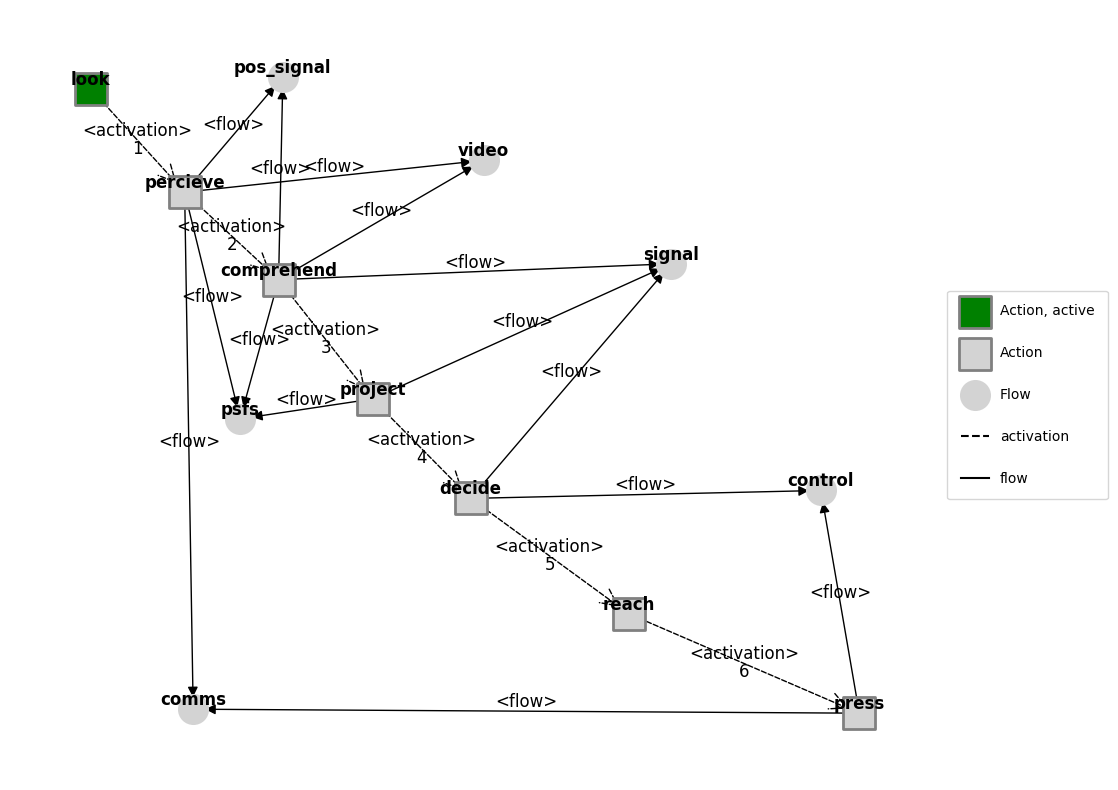

In [5]:
from model_human import RoverHuman, asg_pos
mdl = RoverHuman()
mg = mdl.fxns['operator'].aa.as_modelgraph()
mg.set_pos(**asg_pos)
fig, ax = mg.draw()

## Human Modeling

Given this representation, we can evaluate operator fault modes:

In [6]:
from fmdtools.sim.sample import FaultDomain, FaultSample
fd_hum = FaultDomain(mdl)
fd_hum.add_all_fxn_modes('operator')
fs_hum = FaultSample(fd_hum)
fs_hum.add_fault_phases("start")
ecs, hists = propagate.fault_sample(mdl, fs_hum)

SCENARIOS COMPLETE: 100%|██████████| 19/19 [00:05<00:00,  3.61it/s]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


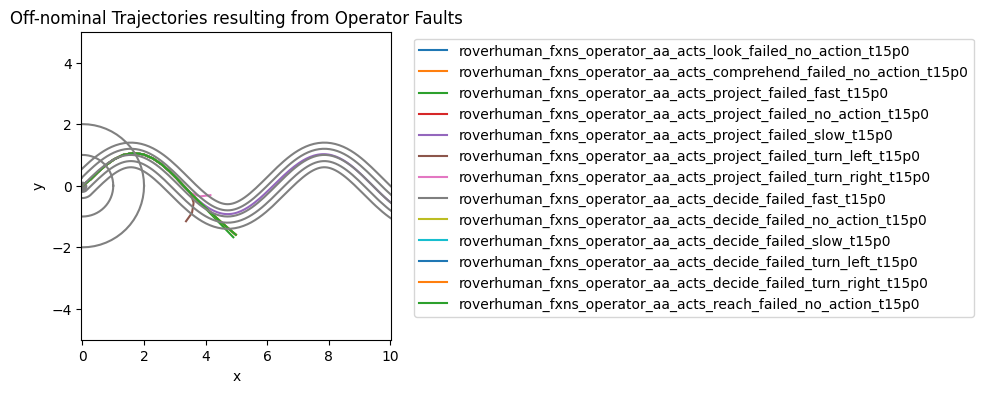

In [9]:
nomx, nomy = hists.nominal.flows.pos.s.x[-1], hists.nominal.flows.pos.s.y[-1]
comp_groups = {h: h for h, k in hists.nest(1).items() if not (k.flows.pos.s.x[-1]==nomx and k.flows.pos.s.y[-1]==nomy)}
gcs = {'shapes': {k: {'color': 'gray'} for k in ['on', 'near', 'shape']}}
geoms = {k: gcs for k in ['start', 'line', 'end']}
fig, ax = plot_map(mdl, hists, geoms=geoms, time_groups=[], comp_groups=comp_groups, coord_kwargs={'legend': False})
ax.set_xlim(0, 10)
ax.set_ylim(-5, 5)
a = ax.set_title("Off-nominal Trajectories resulting from Operator Faults")

## Degradation Modeling {.smaller}

The degradation modeling component of the rover model enables the representation of degraded human and component parameters, such as part wear and stress.

The figures below (generated in `demo_degradation.ipynb`) show the degradation of parameters over time as well as their ability to cause failures.

:::: {.columns}
::: {.column width="50%"}
![](outputs_demo_degradation/stress_degradation.svg)
:::
::: {.column width="50%"}
![](outputs_demo_degradation/stress_fatigue_failures.svg)
:::
::::





## Failure Mode Exploration {.smaller}

The rover has also been used to develop approaches to synthetically generate failure modes.

In this methodology, failure modes are sampled from sets of failure-effecting parameters, as shown below (along with resulting trajectories):


:::: {.columns}
::: {.column width="50%"}
![](outputs_paper_jmd_synthetic_modes/hazard_space.svg)
:::
::: {.column width="50%"}
![](outputs_paper_jmd_synthetic_modes/fault_map.svg)
:::
::::


## Conclusions {.smaller}

The rover model is used as a testbed to develop a number of hazard analysis methodologies for autonomy, including:

- human/autonomous systems modeling, which can be used to represent the high-level actions a human or autonomous systems perform as well as hand-off between human and autonomous systems control,

- human/component degradation modeling, which can be used to represent human performance degradation in autonomous systems control modes, and 

- synthetic failure mode exploration, which can be used to explore the space of potential modes in autonomy-related components (e.g., machine learning component input-output combinations)